# Assignment: Predicting Ice Cream Sales

Welcome to your first assignment!

In this assignment you will build a regression model that predicts **daily ice cream units sold** from weather and date features.
Along the way you will practise the full ML pipeline:

1. **Load Data** — read a multi-row, per-flavour dataset and reshape it into a 3-D tensor
2. **Feature Engineering** — extract meaningful signals from raw dates and temperatures
3. **Data Preparation** — normalise features and build PyTorch tensors
4. **Visualisation** — confirm your pipeline with a quick sanity-check plot
5. **Model Design** — define a small feed-forward network with `nn.Sequential`
6. **Training** — write the training loop and watch the loss converge

> **Dataset:**</br>
`ice_cream_sales.csv` — 3 years of sales data of your ice cream shop</br></br>
The dataset contains is one row per *(date, flavour)* observation.</br>
The four flavours appear in a **fixed order** (`vanilla, chocolate, strawberry, mango`) for every date.</br>
Since there are four flavours, we have four rows for every date.

Your first task is to reshape this flat table into a 3-D tensor and sum across the flavour axis.


## Table of Contents
- [Imports](#imports)
- [1 — Load Data](#section-1)
    - [1.1 — Read the raw CSV](#section-1-1)
    - [1.2 — Reshape and sum using PyTorch tensors](#section-1-2)
        - Step A — Convert to a 2-D tensor
        - Step B — Reshape to 3-D
        - Step C — Extract weather features via slicing
        - Step D — Sum `units_sold` across flavours
        - Step E — Recover dates
- [2 — Feature Engineering](#section-2)
    - [2.1 — Binary flag: `is_weekend`](#section-2-1)
    - [2.2 — Binary flag: `is_hot`](#section-2-2)
    - [2.3 — Binary flag: `is_dry`](#section-2-3)
    - [2.4 — Handling temporal data](#section-2-4)
        - [2.4.1 — One-hot encode the month](#section-2-4-1)
        - [2.4.2 — Trigonometric encoding (optional)](#section-2-4-2)
- [3 — Data Preparation](#section-3)
    - [3.1 — Normalise continuous features](#section-3-1)
    - [3.2 — Assemble feature matrix and target vector](#section-3-2)
- [4 — Visualisation](#section-4)
- [5 — Model Design](#section-5)
- [6 — Training the Model](#section-6)
    - [6.1 — Improve training stability](#section-6-1)
    - [6.2 — Loss curve](#section-6-2)
    - [6.3 — Actual vs. Predicted](#section-6-3)
- [7 — Make a New Prediction (Bonus)](#section-7)
- [Conclusion](#conclusion)

<a name='imports'></a>
## Imports

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

<a name='section-1'></a>
---
## 1 — Load Data

<a name='section-1-1'></a>
### 1.1 Read the raw CSV

The raw file has one row per *(date, flavour)* pair, sorted by date then by
flavour in a **fixed order** (vanilla, chocolate, strawberry, mango):

| date       | flavor    | temperature | precipitation | units_sold |
|------------|-----------|:-----------:|:-------------:|:----------:|
| 2022-01-01 | vanilla   | −1.0        | 0.1           | 13         |
| 2022-01-01 | chocolate | −1.0        | 0.1           | 11         |
| 2022-01-01 | strawberry| −1.0        | 0.1           | 4          |
| 2022-01-01 | mango     | −1.0        | 0.1           | 1          |
| 2022-01-02 | vanilla   | …           | …             | …          |
| …          | …         | …           | …             | …          |

Load the file and inspect the first few rows.


In [ ]:
file_path = 'https://raw.githubusercontent.com/opencampus-sh/course-material/main/applied-machine-learning/week-01/ice_cream_sales.csv'
raw_df = pd.read_csv(file_path, parse_dates=['date'])

N_FLAVORS = 4
FLAVORS   = ['vanilla', 'chocolate', 'strawberry', 'mango']

# Set the number of rows you want to display.
rows_to_display = 10

# Display the shape, columns and first rows of the DataFrame.
print(f"Raw shape : {raw_df.shape}", end="\n\n")
print(f"Columns   : {list(raw_df.columns)}", end="\n\n")
print(raw_df.head(rows_to_display))

<a name='section-1-2'></a>
### 1.2 Reshape and sum using PyTorch tensors

We want to train our model to predict the total number of daily ice cream units sold.
This number can be computed by adding the number of units sold for each flavour for any given day.

This could be done using pandas `groupby` and `agg` methods, but instead of using pandas `groupby`,
you will work directly with the underlying numbers as a tensor — a much more PyTorch-native approach.

**The key insight:** because the flavour order is the same for every date, the flat table
has a hidden 3-D structure:

* our raw dataframe is only 2-D and has a shape of `(N_days * N_flavors, columns)`
* we want to reshape our dataframe into a 3-D tensor with a shape of `(N_days, N_flavors, columns)`

Once you have that 3-D tensor, you can:
- **slice** along the flavour axis to pick individual columns
- **sum** along the flavour axis to aggregate `units_sold`

Work through the steps below.

#### Step A — Convert the numeric columns to a 2-D tensor

Select `temperature`, `precipitation`, and `units_sold` from `raw_df`
and convert them to a `torch.float32` tensor of shape `(N_days * N_flavors, N_numeric_features)`.

> 💡 The three columns appear in the order listed above in the tensor — remember this for the slicing steps.

In [ ]:
### START CODE HERE ###

# Identify the numeric columns to be used as features for the model.
numeric_cols = None

# Extract the numeric columns and convert them to a Numpy array, then to a PyTorch tensor of type float32.
numeric_cols_as_array = None

numeric_features = torch.tensor(
    numeric_cols_as_array,
    dtype=None
)
### END CODE HERE ###

N_total_rows = numeric_features.shape[0]
N_days = N_total_rows // N_FLAVORS

print(f"numeric_features shape : {numeric_features.shape}")   # (N_days * N_FLAVORS, N_numeric_features)
print(f"N_days                 : {N_days}")


#### Step B — Reshape to 3-D

Use `tensor.reshape()` to turn the flat `(N_days * N_flavors, N_numeric_features)` tensor into
a 3-D tensor of shape `(N_days, N_flavors, N_numeric_features)`.

After reshaping, the dimensions (or axis) of the tensor are:
* `axis 0` = day,
* `axis 1` = flavour,
* `axis 2` = feature.

In [ ]:
### START CODE HERE ###

numeric_features_reshaped = None

### END CODE HERE ###

print(f"numeric_features_reshaped shape : {numeric_features_reshaped.shape}")   # (N_days, N_FLAVORS, N_numeric_features)
print(f"\nFirst day, all flavours:\n(values per flavour are [temperature, precipitation, units_sold])")
print(numeric_features_reshaped[0, :, :])

#### Step C — Extract weather features via slicing

`temperature` and `precipitation` are **identical** across all flavours on the same day (they are day-level measurements, not flavour-level).

We can use tensor slicing to extract these values for a single **representative flavour** (e.g. index 0 = vanilla).

Because we extracted the numeric features in the order `temperature`, `precipitation`, and `units_sold` above:
- `temperature` is at feature index 0
- `precipitation` is at feature index 1

The result should have shape `(N_days,)`.

> **Slicing syntax reminder:**  
> `tensor[dim0, dim1, dim2]` — use `:` to mean "all elements along that axis".


In [ ]:
### START CODE HERE ###

representative_favour_index = None # vanilla

temperature   = numeric_features_reshaped[None, None, None]   # all days, first flavour, first numeric feature
precipitation = numeric_features_reshaped[None, None, None]   # all days, first flavour, second numeric feature

### END CODE HERE ###

print(f"temperature   shape : {temperature.shape}")
print(f"precipitation shape : {precipitation.shape}")

#### Step D — Sum `units_sold` across flavours

`units_sold` is our third numeric feature given by feature index 2.  
Use `.sum(dim=1)` to sum across the flavour axis (axis 1), collapsing
`(N_days, N_flavours)` → `(N_days,)`.


In [9]:
### START CODE HERE ###

# Extract the units_sold column (index 2).
units_sold = numeric_features_reshaped[:, :, 2]    # all days, all flavours, third numeric feature
total_units_sold = units_sold.sum(1)   # shape: (N_days,)

### END CODE HERE ###

print(f"total_units_sold shape : {total_units_sold.shape}")
print(f"Min / Mean / Max       : {total_units_sold.min():.0f} / {total_units_sold.float().mean():.1f} / {total_units_sold.max():.0f}")


total_units_sold shape : torch.Size([1096])
Min / Mean / Max       : 0 / 59.7 / 272


#### Step E — Recover dates

The date column stayed in `raw_df`. Extract one date per day by taking every `N_FLAVORS`-th row.


In [10]:
dates = raw_df['date'].iloc[::N_FLAVORS].reset_index(drop=True)

print(f"dates length : {len(dates)}")

assert len(dates) == N_days, "Mismatch between dates and N_days — check your reshape!"

dates length : 1096


<a name='section-2'></a>
---
## 2 — Feature Engineering

Theoretically, with infinite data, infinite compute and the most generic model structure possible, a model should be able to learn hidden relationships in the data.</br>
However, we are always limited in these aspects, we can apply our domain knowledge and tell the model what is important by engineering features describing crucial relations in our data.

In that sense, feature engineering can be seen as a form of **inductive bias** (a deliberate decision we make to support the learning process of the model).</br>
Another form of **inductive bias** is <u>*architectural inductive bias*</u>, where we engineer the structure of the model to support the learning process. We will come back to this later in the course.

For our dataset, the raw dates and temperatures carry a lot of *implicit* structure that a model cannot easily discover on its own.</br>
This section turns that implicit structure into explicit features.


<a name='section-2-1'></a>
### 2.1 Binary flag: `is_weekend`

Weekend days tend to see higher foot traffic and therefore more ice cream sales.</br>
Create a Boolean (0/1) tensor `is_weekend` (using `torch.tensor()`) that is **1 on Saturdays and Sundays**.

In [12]:
### START CODE HERE ###

# Get the days of the week by taking every `N_FLAVORS`-th row.
days_of_week = dates.dt.dayofweek # 0=Mon … 6=Sun

is_weekend = torch.tensor(days_of_week >= 5)

is_weekend = is_weekend.float()   # Convert the boolean tensor to a float tensor to keep as tensor (0. / 1.)

### END CODE HERE ###

print(f"is_weekend shape       : {is_weekend.shape}")
print(f"Weekend days in dataset: {is_weekend.sum():.0f} / {len(is_weekend)}")

is_weekend shape       : torch.Size([1096])
Weekend days in dataset: 314 / 1096


<a name='section-2-2'></a>
### 2.2 Binary flag: `is_hot`

People are much more likely to buy ice cream on hot days.</br>
Assume that **"hot" is defined as temperatures ≥ 25 °C** and create a binary (0/1) tensor `is_hot`.

In [15]:
### START CODE HERE ###

HOT_THRESHOLD = 25   # °C

is_hot = torch.tensor(temperature >= HOT_THRESHOLD)

is_hot = is_hot.float()   # Convert the boolean tensor to a float tensor to keep as tensor (0. / 1.)

### END CODE HERE ###

print(f"Hot days in dataset: {is_hot.sum():.0f} / {len(is_hot)}")

Hot days in dataset: 49 / 1096


/tmp/ipykernel_4076/1158814547.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  is_hot = torch.tensor(temperature >= HOT_THRESHOLD)


<a name='section-2-3'></a>
### 2.3 Binary flag: `is_dry`

People are much more likely to buy ice cream days without precipitation.</br>
Assume that **"dry" as precipitation ≤ 1.0 mm** and create a binary (0/1) tensor `is_dry`.

In [16]:
### START CODE HERE ###

DRY_THRESHOLD = 1.0   # mm

is_dry = torch.tensor(precipitation <= DRY_THRESHOLD)

is_dry = is_dry.float()   # Convert the boolean tensor to a float tensor to keep as tensor (0. / 1.)

### END CODE HERE ###

print(f"Dry days in dataset: {is_dry.sum():.0f} / {len(is_dry)}")

Dry days in dataset: 861 / 1096


/tmp/ipykernel_4076/2835274137.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  is_dry = torch.tensor(precipitation <= DRY_THRESHOLD)


<a name='section-2-4'></a>
### 2.4 Handling temporal data

Dealing with temporal information can be tricky.

Our models almost always include at least one linear layer, that computes $z = w_{1}x_{1} + \cdots + b$.</br>

Run the cell below. Observe that the model would see Dec 31 and Jan 1 as 364 days apart, even though they are consecutive calendar days.

In [17]:
# Run and observe, nothing to change
dec31 = pd.Timestamp('2023-12-31').day_of_year
jan01 = pd.Timestamp('2024-01-01').day_of_year

print(f"Dec 31 ordinal : {dec31}")
print(f"Jan  1 ordinal : {jan01}")
print(f"Model 'distance': {abs(dec31 - jan01)} days")
print("Even if the two timestep are only one day apart, considering only the day of the year creates a strong numerical cliff in the data!")

Dec 31 ordinal : 365
Jan  1 ordinal : 1
Model 'distance': 364 days
Even if the two timestep are only one day apart, considering only the day of the year creates a strong numerical cliff in the data!


---
> #### 🤔 **Discussion:** How does the model handle this raw data and why could this be problematic?
> Think about what would happen, if we would simply plug in our raw temporal data (e.g. the month) as $x_{1}$ in such a model.

`### ADD YOUR DISCUSSION AND IDEAS HERE ###`

These considerations apply to any kind of temporal and sequential data and there are different strategies to overcome these issues.

You have already used one approach when creating the binary flag `is_weekend`.

Below you can see a table of some strategies, that we can use when dealing with temporal data and sequential data.


| Strategy | Complexity | Intuition | Notes |
|----------|------------|-----------|-------|
| Raw ordinal (1–365) | Very Low | Low | Creates a "cliff" between Dec 31 and Jan 1 |
| Binary flag | Very Low | High | Already done when defining `is_weekend` |
| One-hot (month) | Low | High | Treats July as its own entity — visual and logical |
| Trig (sin/cos of day-of-year) | Medium | Medium | Solves the cliff and preserves circular structure |

The other two strategies will briefly be discussed below.

<a name='section-2-4-1'></a>
#### 2.4.1 One-hot encode the month

We can create 11 binary columns `month_2` … `month_12` using `pd.get_dummies`.

Because the 11 columns are sufficient to also describe `month_1` (we know, it's January, when all columns `month_2` … `month_12` are zero),</br>
we drop `month_1` as the reference category to avoid multicollinearity.

**Hint:** Extract the month number from `dates` first, then pass it to `pd.get_dummies`
with `prefix='month'` and `drop_first=True`.


In [18]:
fmonths_one_hot = torch.tensor(
    pd.get_dummies(
        dates.dt.month,
        prefix='month',
        drop_first=True,    # drops month_1; keeps month_2 … month_12
        dtype=float,
    ).to_numpy(dtype='float32'),
)   # shape: (N_days, 11)

print(f"months_one_hot shape : {months_one_hot.shape}")

months_one_hot shape : torch.Size([1096, 11])


<a name='section-2-4-2'></a>
#### 2.4.2 Trigonometric encoding (optional)

We can create two new features based on the day of the year: a sine and a cosine wave.</br>
When you use both features together, you map the time feature onto a circle in a 2D space ad every day of the year becomes a unique coordinate $(x, y)$ on that circle.

Sine/cosine encoding preserves the *circular* geometry of the calendar:
December and January remain neighbours, unlike the ordinal encoding.

$$
\text{day\_sin} = \sin\!\left(\frac{2\pi \cdot d}{365}\right), \quad
\text{day\_cos} = \cos\!\left(\frac{2\pi \cdot d}{365}\right)
$$

where $d$ is the day-of-year.


Add these as extra features — you do *not* need to include them in your model.


In [19]:
doy_tensor = torch.tensor(dates.dt.day_of_year.values, dtype=torch.float32)
day_sin    = torch.sin(2 * torch.pi * doy_tensor / 365)   # shape: (N_days,)
day_cos    = torch.cos(2 * torch.pi * doy_tensor / 365)   # shape: (N_days,)

<a name='section-3'></a>
---
## 3 — Data Preparation

<a name='section-3-1'></a>
### 3.1 Normalise continuous features

Standardise the numeric features `temperature` and `precipitation` so each has mean ≈ 0 and std ≈ 1.

$$x' = \frac{x - \mu}{\sigma}$$

The remaining binary and one-hot columns are left as-is.


In [20]:
temp_mean,   temp_std   = temperature.mean(),   temperature.std()
precip_mean, precip_std = precipitation.mean(), precipitation.std()

### START CODE HERE ###

temp_norm   = (temperature - temp_mean)/ temp_std    # tensor, shape: (N_days,)
precip_norm = (precipitation -precip_mean)/ precip_std  # tensor, shape: (N_days,)

### END CODE HERE ###

print(f"temperature   — mean: {temp_norm.mean():.3f}, std: {temp_norm.std():.3f}")
print(f"precipitation — mean: {precip_norm.mean():.3f}, std: {precip_norm.std():.3f}")

temperature   — mean: -0.000, std: 1.000
precipitation — mean: -0.000, std: 1.000


<a name='section-3-2'></a>
### 3.2 Assemble feature matrix and target vector

Now we have finally prepared all of our data and can combine them into a single feature matrix that we can use to train our model.

Create a single feature matrix by using `torch.cat` below and concatenate the individual feature vectors such that the resulting feature matrix has a shape of `(N_days, N_features)`.

In [21]:
### START CODE HERE ###

features = torch.cat([
        temp_norm.unsqueeze(1),  # Temperature   (continuous — normalised)                                   → (N_days, 1)
        precip_norm.unsqueeze(1),  # Precipitation (continuous — normalised)                                   → (N_days, 1)
        is_weekend.unsqueeze(1),  # Weekend       (binary)                                                    → (N_days, 1)
        is_hot.unsqueeze(1),  # Hot           (binary)                                                    → (N_days, 1)
        is_dry.unsqueeze(1),  # Dry           (binary)                                                    → (N_days, 1)
        months_one_hot                # Months        (one-hot, 11 columns, already 2-D, no unsqueeze needed)     → (N_days, 11)
    ], dim=1)

### END CODE HERE ###

targets = total_units_sold.float().unsqueeze(1)   # (N_days, 1)

print(f"features shape : {features.shape}")   # (N_days, 16)
print(f"targets  shape : {targets.shape}")    # (N_days, 1)

features shape : torch.Size([1096, 16])
targets  shape : torch.Size([1096, 1])


<a name='section-4'></a>
---
## 4 — Visualisation

<a name='section-4-1'></a>
### 4.1 Sanity-check plots

Two quick plots before training:

1. **Time series** — the seasonal pattern should be clearly visible.
2. **Temperature vs sales** — look for the non-linear "flat then steep" shape.
   This is precisely the relationship that a network with ReLU activations can
   model, but a purely linear model cannot.


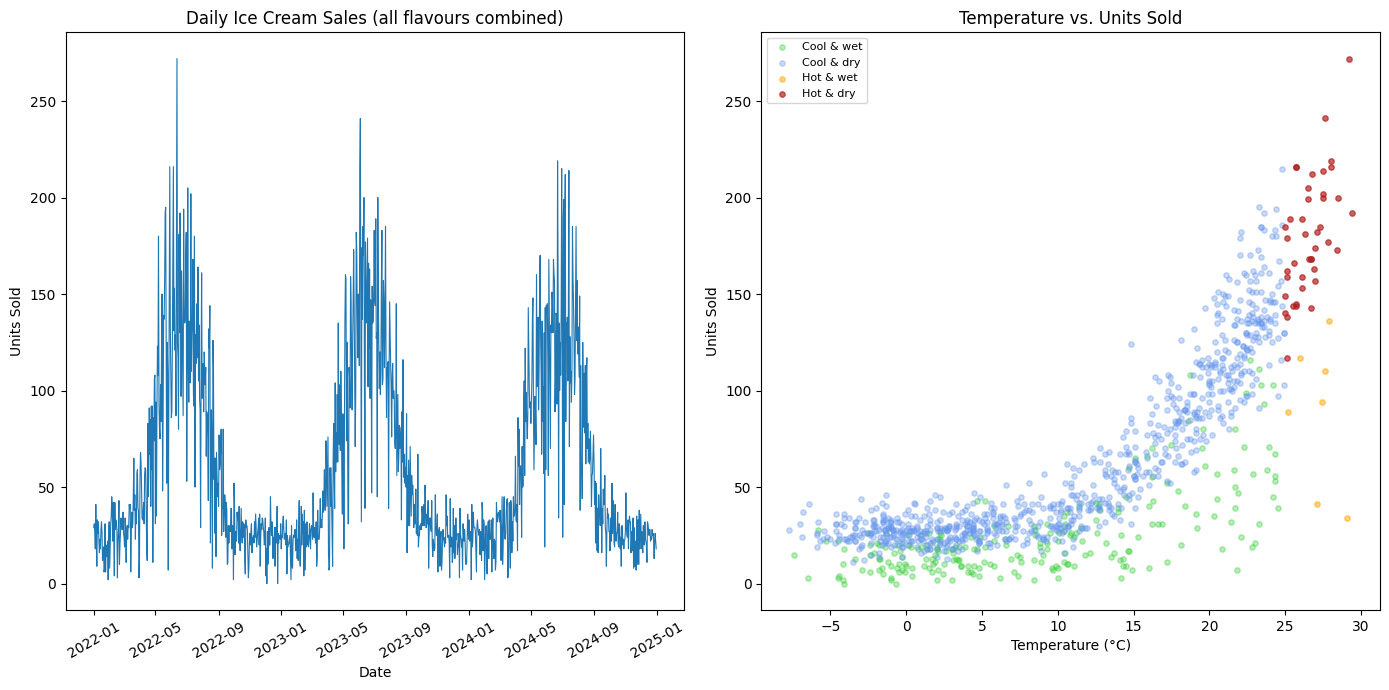

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# ── Left: time series ──
axes[0].plot(dates.values, total_units_sold.numpy(), linewidth=0.8)
axes[0].set_title('Daily Ice Cream Sales (all flavours combined)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Units Sold')
axes[0].tick_params(axis='x', rotation=30)

# ── Right: temperature vs sales, coloured by heat and dryness ──
temp_raw = temperature.numpy()
units_np = total_units_sold.numpy()
hot_mask = is_hot.bool()
dry_mask = is_dry.bool()

# Four groups: hot & dry, hot & wet, cool & dry, cool & wet
hd =  hot_mask &  dry_mask
hw =  hot_mask & ~dry_mask
cd = ~hot_mask &  dry_mask
cw = ~hot_mask & ~dry_mask

axes[1].scatter(temp_raw[cw], units_np[cw], alpha=0.35, s=15, color='limegreen',      label='Cool & wet')
axes[1].scatter(temp_raw[cd], units_np[cd], alpha=0.35, s=15, color='cornflowerblue', label='Cool & dry')
axes[1].scatter(temp_raw[hw], units_np[hw], alpha=0.50, s=15, color='orange',         label='Hot & wet')
axes[1].scatter(temp_raw[hd], units_np[hd], alpha=0.70, s=15, color='firebrick',      label='Hot & dry')
axes[1].set_title('Temperature vs. Units Sold')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Units Sold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
> #### 🤔 **Discussion:** Think about why the temperature relationship of sales might be non-linear?

`### ADD YOUR DISCUSSION AND IDEAS HERE ###`

<details>
  <summary><b>Answer</b> (click to expand)</summary>
  
> In the scatter plot you should see roughly three zones:
> - **Below ~10 °C** — sales are low and almost flat regardless of temperature
> - **10–15 °C** — a gentle ramp begins (shoulder season)
> - **Above ~15 °C** — sales accelerate steeply
>
> This piecewise structure looks a lot like a **ReLU** (Rectified Linear Unit):
> flat for negative inputs, then linearly growing.
> A single linear neuron (`output = w · temperature + b`) can only draw a straight
> line through these points — it will inevitably over-estimate cold-day sales or
> under-estimate hot-day sales.
>
> A network with even **one hidden ReLU layer** can compose multiple hinge functions,
> allowing it to approximate the flat-then-ramp shape much more faithfully.
> This is the core motivation for non-linear activations.
</details>

<a name='section-5'></a>
---
## 5 — Model Design

By now, you should be familiar with the three basic ingredients required for a training:
* Model
* Optimizer
* Loss Function

Your task is therefore to build a regression model that can predict the total units sold based on the features we have extracted and engineered.

**Define a model using `nn.Sequential`.**</br>
The model should have three `nn.Linear` layers, each followed by a `nn.ReLU()` activation function, except for the last one:
* **Input Layer**: An `nn.Linear` layer that accepts **`N_INPUT_FEATURES` input features** (= 16 in our case) and outputs **64 features**.
* **Hidden Layer**: An `nn.Linear` layer that takes the **64 features** from the previous layer and outputs **32 features**.
* **Output Layer**: A final `nn.Linear` layer that takes the **32 features** from the hidden layer and produces a **single output** value.


**Define the Optimizer**
* Use **Stochastic Gradient Descent (SGD)**. As the optimizer will update the parameters of the model, you need to pass `model.parameters()` to the optimizer and also specify a fixed learning rate (`lr`) to `0.01`.

**Define the Loss Function**
* Since we are training a regression model here, we use **Mean Squared Error (MSE)** as the `loss_function`.

In [23]:
N_INPUT_FEATURES = features.shape[1]

# We set a seed for the initialization of the model parameter so our results become reproducible.
torch.manual_seed(42)

### START CODE HERE ###

# Define the model architecture using nn.Sequential
model = nn.Sequential(
    # Input layer (Linear): N_INPUT_FEATURES inputs, 64 output features
    nn.Linear(N_INPUT_FEATURES, 64),
    # First ReLU activation function
    nn.ReLU(),
    # Hidden layer (Linear): 64 inputs, 32 outputs
    nn.Linear(64,32),
    # Second ReLU activation function
    nn.ReLU(),
    # Output layer (Linear): 32 inputs, 1 output (the prediction)
    nn.Linear(32,1),
)

# Define the optimizer (Stochastic Gradient Descent)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Define the loss function (Mean Squared Error for regression)
loss_function = nn.MSELoss()

### END CODE HERE ###

print(model)

Sequential(
  (0): Linear(in_features=16, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)


<a name='section-6'></a>
---
## 6 — Training the Model

Now that we have set up everything, it's finally time to train the model.</br>
Write the training loop and train the model for 10 000 epochs.

For each epoch:

1. Zero the gradients — `optimizer.zero_grad()`
2. Forward pass — `outputs = model(features)`
3. Compute the loss — `loss = loss_function(outputs, targets)`
4. Backward pass — `loss.backward()`
5. Update the parameters — `optimizer.step()`

Print the loss every 1 000 epochs.


In [24]:
### START CODE HERE ###

n_epochs    = 10000
print_every = 1000
loss_history = []

for epoch in range(1, n_epochs + 1):
    # 1. Reset accumulated gradients
    optimizer.zero_grad()

    # 2. Forward pass
    outputs = model(features)

    # 3. Compute loss
    loss = loss_function(outputs, targets)

    # 4. Backward pass — compute gradients
    loss.backward()

    # 5. Update parameters
    optimizer.step()

    # Append the current loss to the history list for later analysis.
    loss_history.append(loss.item())

    if epoch == 1 or epoch % print_every == 0:
        print(f"Epoch [{epoch:>6}/{n_epochs}]  Loss: {loss.item():.2f}")

### END CODE HERE ###

Epoch [     1/10000]  Loss: 6014.49
Epoch [  1000/10000]  Loss: 2440.38
Epoch [  2000/10000]  Loss: 2440.38
Epoch [  3000/10000]  Loss: 2440.38
Epoch [  4000/10000]  Loss: 2440.38
Epoch [  5000/10000]  Loss: 2440.38
Epoch [  6000/10000]  Loss: 2440.38
Epoch [  7000/10000]  Loss: 2440.38
Epoch [  8000/10000]  Loss: 2440.38
Epoch [  9000/10000]  Loss: 2440.38
Epoch [ 10000/10000]  Loss: 2440.38


---
> #### 🤔 **Discussion:** Something seems off here. The loss of the model quickly becomes NaN (not a number).
> This is a classic case of exploding gradients. Think about what might have happened and why our gradients exploded and our model effectively stopped training.

`### ADD YOUR DISCUSSION AND IDEAS HERE ###`

<details>
  <summary><b>Answer</b> (click to expand)</summary>
  
> If you check the `loss_history`, you can see the the loss grows until it becomes infinity (`inf`) and all subsequent losses become `nan` (not a number).</br>
> When defining the model, its parameters (weights and biases) are initialized with small random values.
> The initial predictions of the model will therefore also be small.
> However our target values (total units sold) are roughly in the range of 0 to 250.
> Therefore the MSE loss of the initial prediction and also the gradients of the loss will be quite large.
> Because our optimizer uses a fixed learning rate, the initial updates of the model parameters are just too large and the training becomes unstable.
>
> There are several strategies to overcome this issue of exploding gradients:
> * Use a smaller learning rate (this will generally slow down the training, because the parameter updates will be smaller)
> * Use another optimizer with a variable learning rate or momentum (e.g. `optim.Adam()`)
> * Normalize the target values
>
> We will use the latter approach below, but feel free to try out these strategies. But keep in mind, that you need to re-initialize the parameters of the model, once you have experienced exploding gradients.
> The simplest way to do this, is to simply re-define the model again.
</details>

<a name='section-6-1'></a>
### 6.1 Improve training stability

In [25]:
# Normalise the target variable (units sold) for better training stability.
target_mean  = total_units_sold.float().mean()
target_std   = total_units_sold.float().std()
targets_norm = (total_units_sold.float() - target_mean) / target_std
targets_norm = targets_norm.unsqueeze(1)

In [28]:
# Set the same seed again to ensure the same initial weights for a fair comparison.
torch.manual_seed(42)

### REDEFINE THE MODEL TO RESET THE WEIGHTS (YOU CAN JUST COPY THE CODE FROM THE CELL ABOVE) ###

# Define the model architecture using nn.Sequential
model = nn.Sequential(
    # Input layer (Linear): N_INPUT_FEATURES inputs, 64 output features
    nn.Linear(N_INPUT_FEATURES, 64),
    # First ReLU activation function
    nn.ReLU(),
    # Hidden layer (Linear): 64 inputs, 32 outputs
    nn.Linear(64,32),
    # Second ReLU activation function
    nn.ReLU(),
    # Output layer (Linear): 32 inputs, 1 output (the prediction)
    nn.Linear(32,1),
)

# Define the optimizer (Stochastic Gradient Descent)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Define the loss function (Mean Squared Error for regression)
loss_function = nn.MSELoss()

### END CODE HERE ###

In [ ]:
### START CODE HERE; RETRAIN THE MODEL WITH NORMALIZED TARGETS ###

n_epochs    = 10000
print_every = 1000
loss_history = []

for epoch in range(1, n_epochs + 1):
    # 1. Reset accumulated gradients
    optimizer.zero_grad()

    # 2. Forward pass
    outputs = model(features)

    # 3. Compute loss (KEEP IN MIND TO USE THE NORMALISED TARGETS HERE)
    loss = loss_function(outputs, targets_norm)

    # 4. Backward pass — compute gradients
    loss.backward()

    # 5. Update parameters
    optimizer.step()

    # Append the current loss to the history list for later analysis.
    loss_history.append(loss.item())

    if epoch == 1 or epoch % print_every == 0:
        print(f"Epoch [{epoch:>6}/{n_epochs}]  Loss: {loss.item():.2f}")

### END CODE HERE ###

<a name='section-6-2'></a>
### 6.2 Loss curve

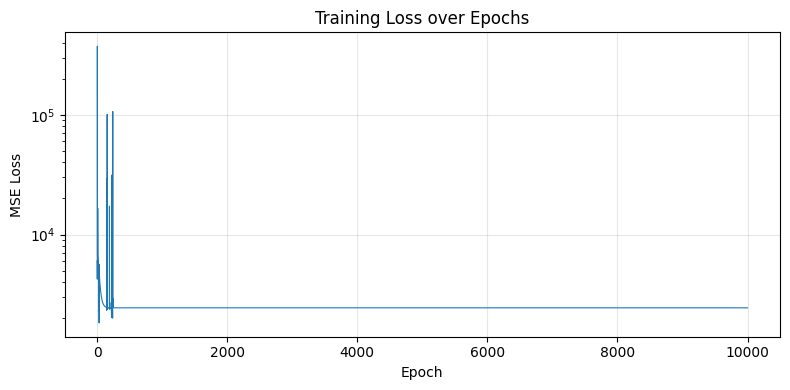

In [29]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, linewidth=0.8)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a name='section-6-3'></a>
### 6.3 Actual vs. Predicted

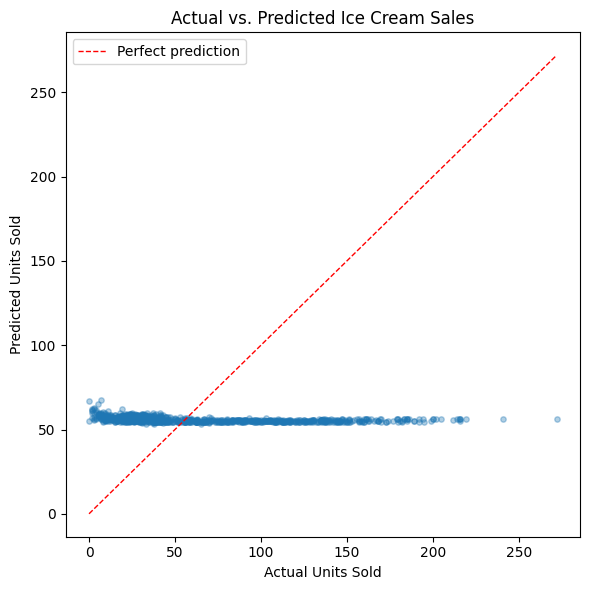

In [30]:
with torch.no_grad():
    # Get raw model output
    preds_norm = model(features).numpy().flatten()

    # Reverse the scaling: x = (x_norm * std) + mean
    predictions = (preds_norm * target_std.item()) + target_mean.item()

actual = total_units_sold.numpy()

plt.figure(figsize=(6, 6))
plt.scatter(actual, predictions, alpha=0.35, s=15)
max_val = max(actual.max(), predictions.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect prediction')
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title('Actual vs. Predicted Ice Cream Sales')
plt.legend()
plt.tight_layout()
plt.show()

<a name='section-7'></a>
---
## 7 — Make a New Prediction (Bonus)

Use your trained model to predict sales for a day of your choice.


In [31]:
### START CODE HERE ###

temperature_new   = 21   # °C
precipitation_new = 2   # mm
is_weekend_new    = 2   # 1 = weekend, 0 = weekday
target_month      = 5   # 1–12

### END CODE HERE ###

# Apply the same normalization used during training
temp_norm_new       = (temperature_new   - temp_mean)   / temp_std
precip_norm_new     = (precipitation_new - precip_mean) / precip_std
is_hot_new          = int(temperature_new >= HOT_THRESHOLD)
is_dry_new          = int(precipitation_new <= DRY_THRESHOLD)

# One-hot months: month_2 … month_12  (month_1 is the dropped reference)
month_onehot = [int(target_month == m) for m in range(2, 13)]

input_values = [temp_norm_new, precip_norm_new, is_weekend_new, is_hot_new, is_dry_new] + month_onehot
input_tensor = torch.tensor([input_values], dtype=torch.float32)

with torch.no_grad():
    # Get raw model output
    predicted_units_norm = model(input_tensor).item()

    # Reverse the scaling: x = (x_norm * std) + mean
    predicted_units = (predicted_units_norm * target_std.item()) + target_mean.item()

print(f"Scenario  : month {target_month}, {'weekend' if is_weekend_new else 'weekday'}, "
      f"{temperature_new} °C {'(hot)' if is_hot_new else '(cold)'}, "
      f"{precipitation_new} mm rain {'(dry)' if is_dry_new else '(wet)'}")
print(f"Predicted : {predicted_units:.1f} units sold")

Scenario  : month 5, weekend, 21 °C (cold), 2 mm rain (wet)
Predicted : 54.6 units sold


---
> #### 🤔 **Discussion:** Could we use this model to help with flavour ordering?
>
> We can now predict total daily sales — great for staffing</br>
  Can we also use this model to figure out how much vanilla or mango to order?

`### ADD YOUR DISCUSSION AND IDEAS HERE ###`

<details>
  <summary><b>Answer</b> (click to expand)</summary>
  
> No — and the reason is fundamental.
> Our model was trained to predict **total** units sold.</br>
> It has never seen per-flavour targets; the flavour dimension was summed away in Step D when loading the data.</br>
> The model has no way to know that 80 % of a hot July day's sales are vanilla,
> while on a mild April day chocolate and strawberry lead.
>
> To answer the ordering question you would need either:
> - **Four separate models**, one per flavour, each trained on that flavour's own `units_sold`
> - **One multi-output model** with a 4-dimensional output head, trained on the full `(N_days, 4)` target matrix
</details>

<a name='conclusion'></a>
---
## Conclusion

Congratulations on completing the assignment!

You have worked through every stage of the ML pipeline:

- **Reshaped** a flat `(N_days × N_flavors, features)` table into a 3-D tensor
  and used slicing and `.sum(dim=1)` to aggregate across the flavour axis
- **Engineered** binary flags (`is_weekend`, `is_hot`, `is_dry`) and explored three strategies for encoding time: ordinal (and why it fails), one-hot, and trigonometric encoding
- **Normalised** continuous features and assembled a PyTorch feature matrix
- **Designed** a feed-forward network with `nn.Sequential` and ReLU activations
- **Written** the training loop step-by-step, saw exploding gradient in action and eventually watched MSE converge after also normalising the target values

Key takeaways:

- The piecewise non-linear relationship between temperature and sales is exactly
  what ReLU activations are designed to capture.
- The choice of temporal encoding matters: the raw temporal data create an ordinal "cliff" between Dec 31 and
  Jan 1.
- Aggregating targets hides information: the aggregate model cannot tell you how
  much vanilla vs. mango to order — that requires per-flavour targets.
